In [53]:
# Step 1
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt


#Step 2
#x5 = np.random.normal(-2,2,(400,1))
# x2 = np.random.randrange(2,2,400)

# x_1 = np.random.random((200,1))*2
# x_2 = np.random.random((200,1))*-2
# x1 = np.concatenate([x_1,x_2], axis = 0)

# x3 = np.random.random((200,1))*2
# x4 = np.random.random((200,1))*-2
# x2 = np.concatenate([x3,x4], axis = 0)
#print(x1)


#set random seed
np.random.seed(82)

#Generate class 0 & 1 sample
x3 = np.random.randn(200,2) + np.array([-2,2])
x4 = np.random.randn(200,2) + np.array([2,-2])

#Stack them together
x = np.concatenate([x3,x4], axis = 0)

#Class labels 0 & 1
y = np.random.randint(0,2,(400,1))
print(x.shape,y.shape)

#Shuffle the dataset
# np.random.shuffle(x)

#print(x)
#print(y)
#from sklearn.model_selection import train_test_split

(400, 2) (400, 1)


In [54]:
#Step 3
#Splitting data
x_train = x[:300,:]
x_test = x[300:,:]
print(x_train.shape, x_test.shape)

y_train = y[:300,:]
y_test = y[300:,:]
print(y_train.shape, y_test.shape)

(300, 2) (100, 2)
(300, 1) (100, 1)


In [55]:
#Step 4
#Initializing model parameter
# w = np.random.random((2,1))
w = np.zeros((2,1))
alpha = 0.001
epoch = 20000
loss_hist = []

In [56]:
#step 5
def sigmoid(z):
    return 1/(1+np.exp(-z))


#step 6
def binary_cross_entropy(y_train, y_hat):
    n = y_train.shape[0]  #300
    loss = - (y_train*np.log1p(y_hat) - (1-y_train)*np.log1p(1-y_hat))
    loss = loss.sum()/n #loss.mean()
    return loss

In [57]:
#step 7
for i in range(epoch):
    y_hat = sigmoid (x_train @ w) #(300,2)*(2,1) = (300,1)
    loss = binary_cross_entropy(y_train, y_hat)
    loss_hist.append(loss)
    
    train_size = x_train.shape[0]
    gradient = (1/train_size)*(x_train.T @ (y_hat - y_train))   # (2,300)*(300,1) = (2,1)
    w = w - alpha * gradient

#print(loss_hist)

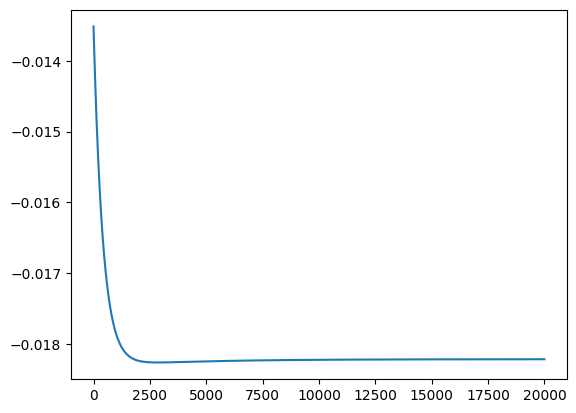

In [58]:
#Step 8  -> Plotting data
plt.plot(loss_hist)
plt.show()

In [59]:
# Step 9 -> Evalution metrics
y_pred = x_test @ w  # (100,2)*(2,1) = (100,1)
y_pred = sigmoid(y_pred)
#print(y_pred)
y_pred = y_pred > 0.5

correct = (y_pred == y_test).sum()
test_size = y_test.shape[0]
accuracy = correct*100 / test_size
print("Accuracy :- ", accuracy)

Accuracy :-  52.0
